In [1]:
import pandas as pd
import tensorflow as tf
import tensorflow.keras as ks

I0000 00:00:1778172044.770709  166654 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778172044.771134  166654 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778172044.805371  166654 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778172045.718382  166654 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
df = pd.read_csv("letter-recognition/letter-recognition.data")
df.shape

(19999, 17)

In [3]:
df.head()

,T,2,8,3,5,1,8.1,13,0,6,6.1,10,8.2,0.1,8.3,0.2,8.4
0,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
1,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
2,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
3,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10
4,S,4,11,5,8,3,8,8,6,9,5,6,6,0,8,9,7


In [4]:
x = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

y = LabelEncoder().fit_transform(y)
x = StandardScaler().fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)


In [6]:
model = ks.models.Sequential([
    ks.layers.Dense(64, activation='relu'),
    ks.layers.Dense(32, activation='relu'),
    ks.layers.Dense(26, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

E0000 00:00:1778172046.728614  166654 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778172046.728918  166795 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778172046.746339  166654 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
history=model.fit(x_train, y_train, epochs=10, verbose=1)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 889us/step - accuracy: 0.5360 - loss: 1.7422
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 892us/step - accuracy: 0.7539 - loss: 0.8544
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 886us/step - accuracy: 0.8007 - loss: 0.6822
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 923us/step - accuracy: 0.8287 - loss: 0.5811
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step - accuracy: 0.8503 - loss: 0.5097
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 898us/step - accuracy: 0.8663 - loss: 0.4529
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 921us/step - accuracy: 0.8772 - loss: 0.4087
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step - accuracy: 0.8873 - loss: 0.3742
Epoch 9/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step - accuracy: 0.8976 - loss: 0.3435
Epoch 10/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step - accuracy: 0.9054 - loss: 0.3182


In [8]:
history.history

{'accuracy': [0.5359709858894348,
  0.7538596391677856,
  0.8006750345230103,
  0.8287392854690552,
  0.8503031730651855,
  0.8663041591644287,
  0.8771798014640808,
  0.8873054385185242,
  0.8976185917854309,
  0.9053691029548645],
 'loss': [1.7422189712524414,
  0.8543806672096252,
  0.6821753978729248,
  0.5811487436294556,
  0.5097294449806213,
  0.45293882489204407,
  0.4087018370628357,
  0.3741983473300934,
  0.3435109555721283,
  0.31817367672920227]}

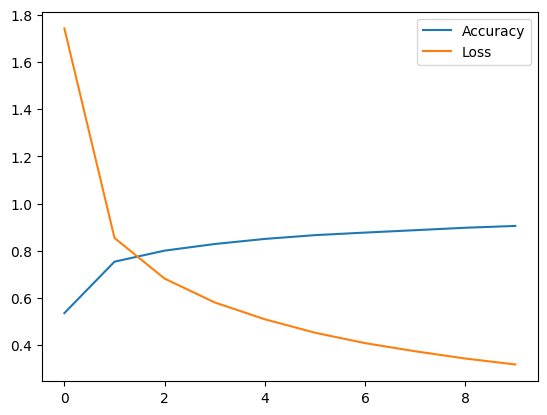

In [10]:
from matplotlib import pyplot as plt

plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['loss'], label='Loss')
plt.legend()
plt.show()

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 774us/step
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       159
           1       0.84      0.94      0.89       168
           2       0.85      0.91      0.88       131
           3       0.93      0.85      0.89       169
           4       0.85      0.84      0.84       150
           5       0.93      0.80      0.86       132
           6       0.83      0.83      0.83       158
           7       0.82      0.78      0.80       154
           8       0.97      0.89      0.92       157
           9       0.91      0.91      0.91       159
          10       0.88      0.91      0.90       151
          11       0.95      0.92      0.93       153
          12       0.87      0.94      0.90       149
          13       0.90      0.90      0.90       165
          14       0.84      0.76      0.80       142
          15       0.90      0.90      0.90       139
          16       0.83      0.90     

<Axes: >

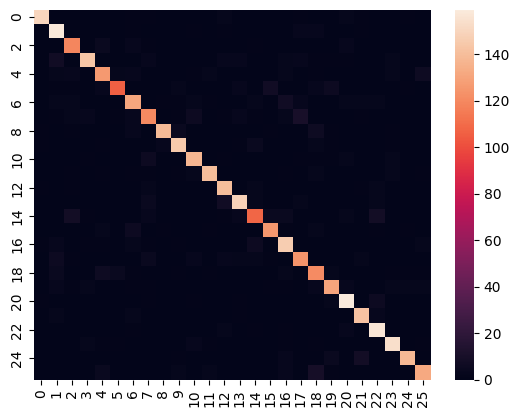

In [13]:
y_pred = model.predict(x_test)
y_pred = y_pred.argmax(axis=1)

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred))